# **Signal Homework 06** Notebook

## **Install Dependencies**

In [1]:
%pip install -qq praat-parselmouth

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np

from scipy import signal, fftpack

import cv2
from skimage.io import imread

import matplotlib.pyplot as plt
import IPython.display as ipd

---

## **Problem 1** (sound)
Denoising time with FFT (DFT)

In [3]:
# SET RANDOM SEED
np.random.seed(42)

# parameters
sampling_rate = 32000

N = 10001
Nf = 3 # Nf--> num freq
t = np.arange(N, dtype=float)

# pick rand period between 10-2010 and convert to freq
Ts = np.random.rand(Nf) * 2000 + 10
fs = 1 / Ts

# fs in sampling rate
fs_real = fs * sampling_rate

# pick rand Amp and phase
amp = np.random.rand(Nf) * 200 + 100
phi = np.random.rand(Nf) * 2 * np.pi

# create clean signal
h = np.zeros(N)
for i in range(len(fs)):
    h += amp[i] * np.sin(2 * np.pi * fs[i] * t + phi[i])

# signal with noise
h_w_noise = h + np.random.randn(N) * 3 * h + np.random.randn(N) * 700

### **TODO 1.1 :** plot (1) clean signal and (2) noisy signal with label

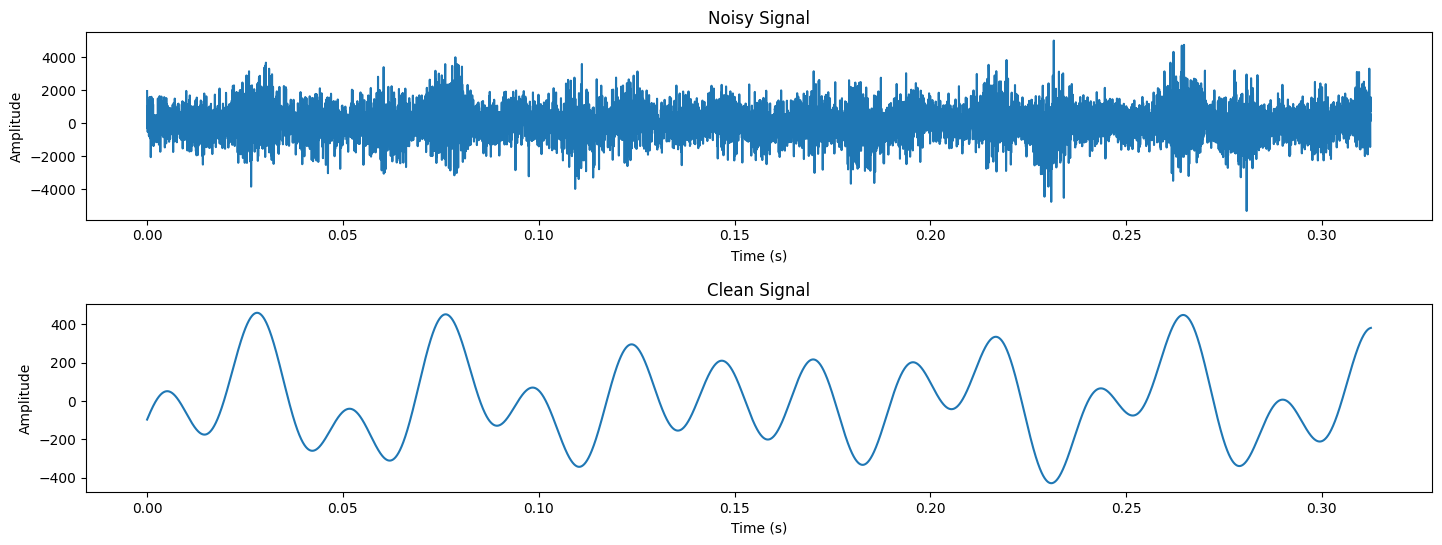

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
plt.tight_layout(pad=4)

signals = [(h_w_noise, "Noisy Signal"), (h, "Clean Signal")]

for ax, (signal, title) in zip(axes, signals):
    ax.plot(t / sampling_rate, signal)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.show()

### **TODO 1.2**: plot magnitude of FFT of the noisy signal (freq sort form min --> max)

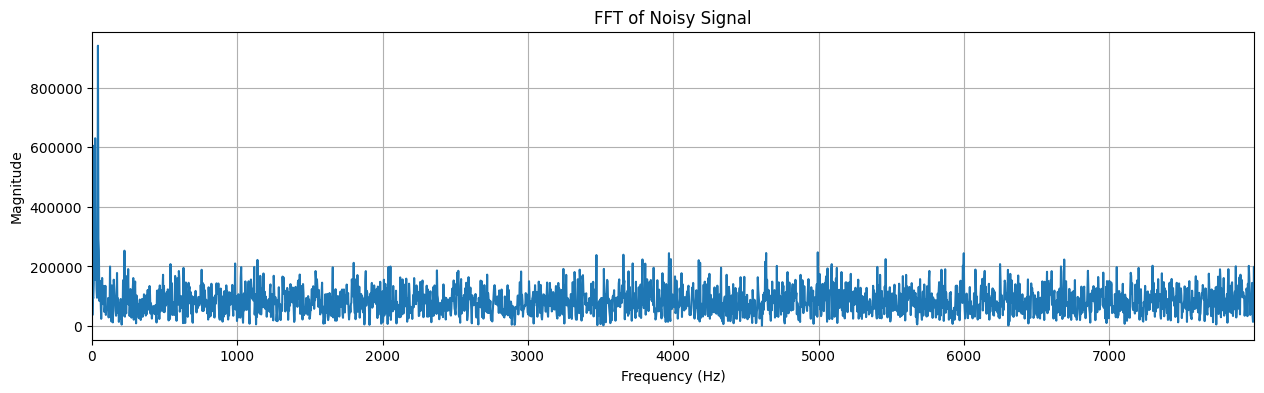

In [5]:
h_w_noise_fft = fftpack.fft(h_w_noise)
freqs = fftpack.fftfreq(len(h_w_noise_fft), 1 / sampling_rate)

magnitude = np.abs(h_w_noise_fft[np.argsort(freqs)])
freqs = np.sort(freqs)

plt.figure(figsize=(15, 4))

plt.plot(freqs, magnitude)

plt.title("FFT of Noisy Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, min(10000, np.max(freqs)/2))

plt.grid()
plt.show()

### **TODO 1.3 :** cleaning the noisy signal using magnitude of FFT

In [6]:
h_w_noise_fft_cleaned = h_w_noise_fft.copy()

# Calculate magnitude of FFT components
magnitude = np.abs(h_w_noise_fft_cleaned)

# Filtering: keep components with magnitude above threshold
threshold = np.max(magnitude) / 3
mask = magnitude > threshold

# Apply the mask to keep only significant frequency components
h_w_noise_fft_cleaned = h_w_noise_fft_cleaned * mask

# inverse FFT to get cleaned signal
h_cleaned = fftpack.ifft(h_w_noise_fft_cleaned).real

print(f"Number of components kept: {np.sum(mask)} out of {len(mask)}")
print(f"Percentage of components kept: {100 * np.sum(mask) / len(mask):.3f}%")
print(f"Magnitude range of kept components: {np.min(magnitude[mask]):.2f} to {np.max(magnitude[mask]):.2f}")

Number of components kept: 6 out of 10001
Percentage of components kept: 0.060%
Magnitude range of kept components: 605369.89 to 940378.95


### **TODO 1.4 :** plot clean signal, noise signal and filtered signal (from your result in TODO 1.3) with label

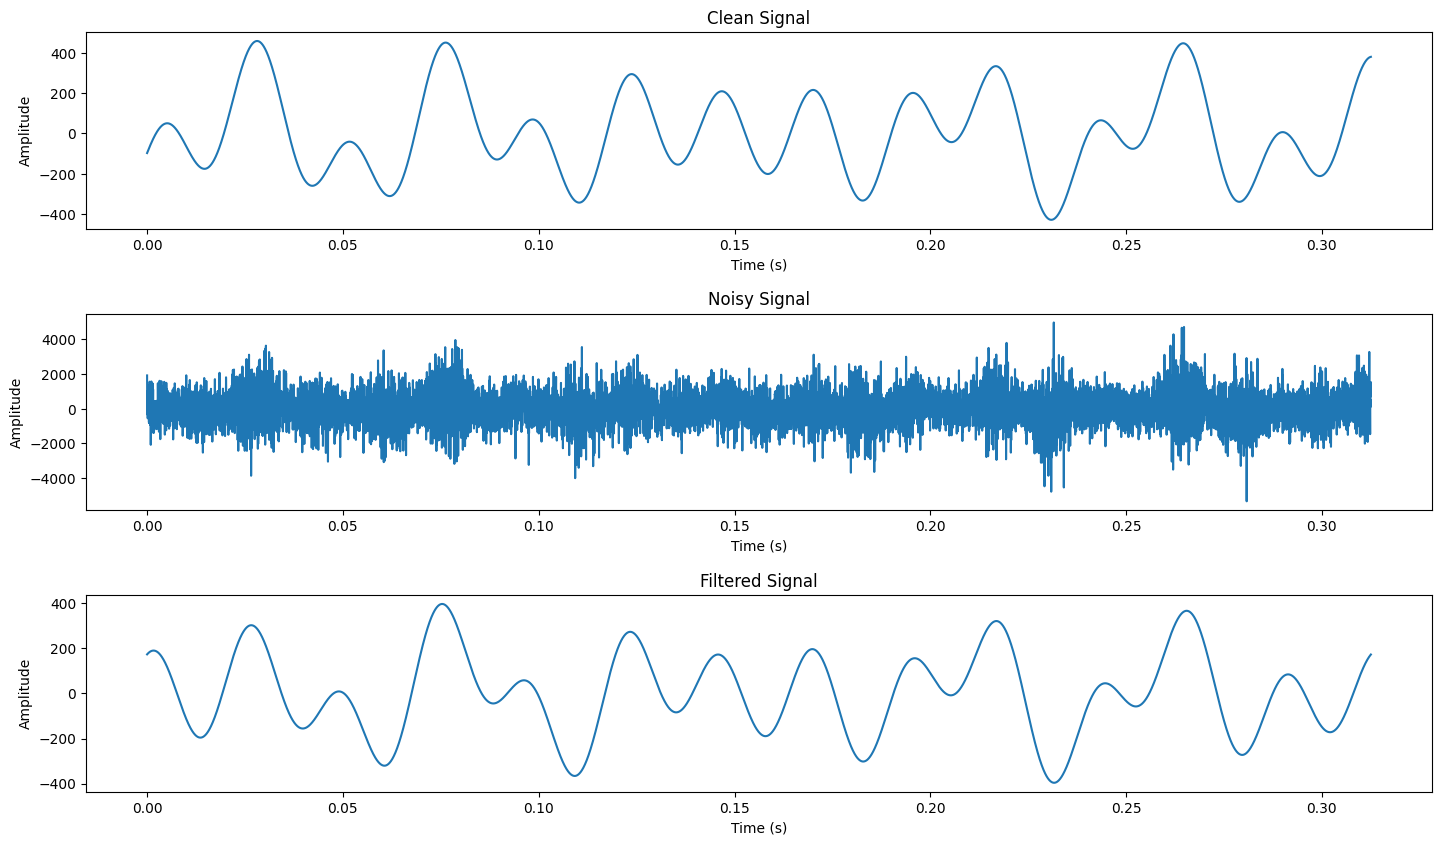

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
plt.tight_layout(pad=4)
signals = [(h, "Clean Signal"), (h_w_noise, "Noisy Signal"), (h_cleaned, "Filtered Signal")]
for ax, (signal, title) in zip(axes, signals):
    ax.plot(t / sampling_rate, signal)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.show()

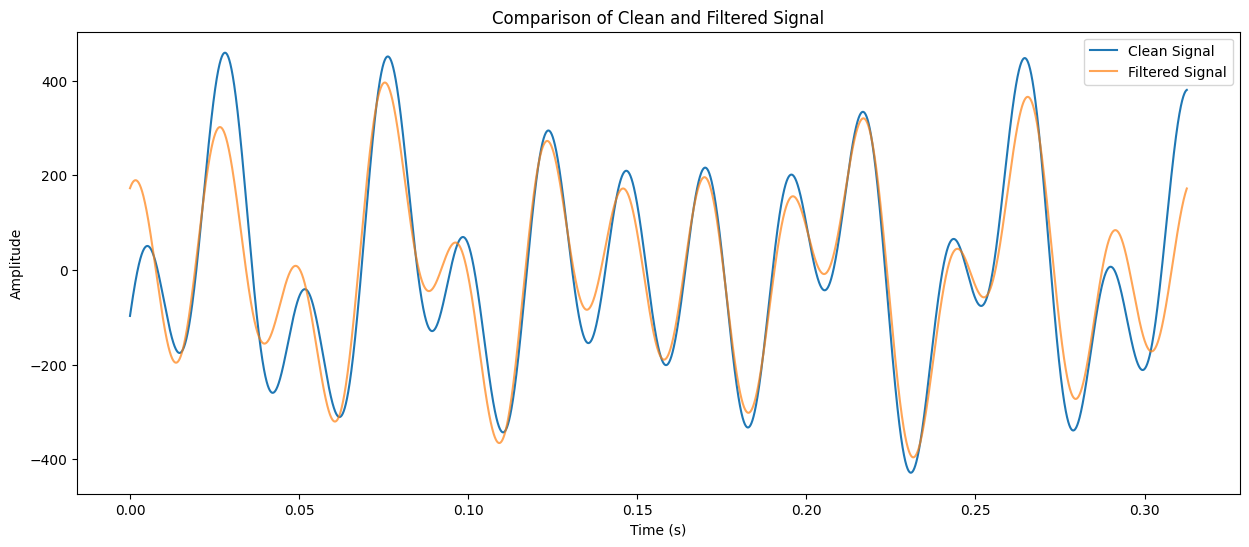

In [8]:
# Compare Clean and Filtered Signal

plt.figure(figsize=(15, 6))

plt.plot(t / sampling_rate, h, label="Clean Signal")
plt.plot(t / sampling_rate, h_cleaned, label="Filtered Signal", alpha=0.7)

plt.title("Comparison of Clean and Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.legend()
plt.show()

### **TODO 1.5 :** export with IPython.display, listen to (1) original signal (2) signal with noise (3) signal after filtered

In [9]:
print("Original Clean Signal:")
ipd.display(ipd.Audio(h, rate=sampling_rate))

print("Noisy Signal:")
ipd.display(ipd.Audio(h_w_noise, rate=sampling_rate))

print("Filtered Signal:")
ipd.display(ipd.Audio(h_cleaned, rate=sampling_rate))

Original Clean Signal:


Noisy Signal:


Filtered Signal:


### **TODO 1.6 :** Write to explain and analyze the results

**Explanation**

This problem demonstrates the application of Fast Fourier Transform (FFT) for signal denoising. We start with a clean signal composed of 3 sinusoidal components, add noise to it, and then use FFT-based filtering to recover the original signal.

<br>

**Step 1: Signal Generation and Visualization (TODO 1.1)**

First, we generate a clean signal and add noise:
```python
# Clean signal generation
h = np.zeros(N)
for i in range(len(fs)):
    h += amp[i] * np.sin(2 * np.pi * fs[i] * t + phi[i])

# Add noise
h_w_noise = h + np.random.randn(N) * 3 * h + np.random.randn(N) * 700
```

The plotting shows that the noisy signal has significant amplitude variations and distortions compared to the smooth, periodic clean signal. The noise consists of both multiplicative noise (proportional to the signal) and additive white noise.

<br>

**Step 2: Frequency Domain Analysis (TODO 1.2)**

We analyze the frequency content using FFT:
```python
h_w_noise_fft = fftpack.fft(h_w_noise)
freqs = fftpack.fftfreq(len(h_w_noise_fft), 1 / sampling_rate)
magnitude = np.abs(h_w_noise_fft[np.argsort(freqs)])
```

The FFT magnitude plot reveals distinct peaks at specific frequencies corresponding to the original signal components, while noise appears as a broad-spectrum background with much lower magnitude values.

<br>

**Step 3: Signal Filtering (TODO 1.3)**

We implement magnitude-based filtering:
```python
magnitude = np.abs(h_w_noise_fft_cleaned)
threshold = np.max(magnitude) / 3
mask = magnitude > threshold
h_w_noise_fft_cleaned = h_w_noise_fft_cleaned * mask
h_cleaned = fftpack.ifft(h_w_noise_fft_cleaned).real
```

This approach keeps only frequency components with magnitude above one-third of the maximum magnitude. Since the original signal has only 3 sinusoidal components with high amplitudes, this threshold effectively separates signal from noise.

<br>

**Step 4: Results Comparison (TODO 1.4)**

The comparison plots show that:
- The filtered signal closely matches the original clean signal
- Most of the noise has been successfully removed
- The fundamental frequency components and their relationships are preserved

<br>

**Step 5: Audio Analysis (TODO 1.5)**

Listening to the audio confirms our visual analysis:
```python
ipd.display(ipd.Audio(h, rate=sampling_rate))          # Clean
ipd.display(ipd.Audio(h_w_noise, rate=sampling_rate))  # Noisy  
ipd.display(ipd.Audio(h_cleaned, rate=sampling_rate))  # Filtered
```

The filtered audio sounds significantly clearer than the noisy version and very similar to the original clean signal.

<br>

**Conclusion**

FFT-based filtering is highly effective for signals with distinct frequency components. The key insight is that signal components typically have much higher magnitude in the frequency domain compared to random noise. By applying an appropriate threshold, we can preserve the essential signal characteristics while removing unwanted noise. This method works particularly well when the signal has a sparse frequency representation, as in this case with only 3 sinusoidal components.

---

## **Problem 2** (image FFT)
Download a 1000 x 1000 image (`"hamtaro.png"`) below

<a href="https://ibb.co/kHTjZbb"><img src="https://i.ibb.co/kHTjZbb/hamtaro.png" alt="hamtaro" border="0"></a>

libpng warning: eXIf: duplicate


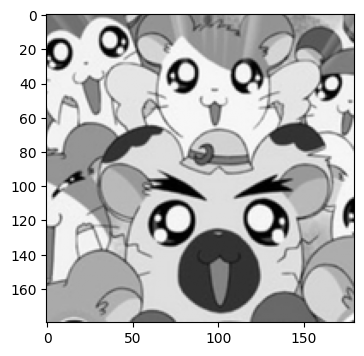

In [10]:
# Download the image first
import urllib.request

# Download the hamtaro image
url = "https://i.ibb.co/kHTjZbb/hamtaro.png"
filepath = "../images/hamtaro.png"
os.makedirs(os.path.dirname(filepath), exist_ok=True)

urllib.request.urlretrieve(url, filepath)

# Read the image
screen_shot = cv2.imread(filepath, 0)

# Check if image was loaded successfully
if screen_shot is None:
	print("Error: Could not load image")
else:
	plt.figure(figsize=(4, 4))
	plt.imshow(screen_shot, cmap="gray")
	plt.show()

libpng warning: eXIf: duplicate


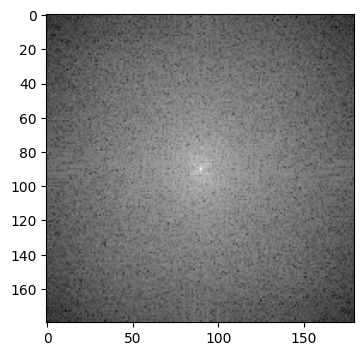

In [11]:
# Read the image
screen_shot = cv2.imread(filepath, 0)
screen_shot = screen_shot if screen_shot is not None else np.zeros((256, 256))

# Apply FFT to the given image
F1 = fftpack.fft2((screen_shot).astype(float))
F2 = fftpack.fftshift(F1) # FFT center zeros freq

plt.figure(figsize=(4, 4))
plt.imshow((20 * np.log10(0.1 + np.abs(F2))).astype(int), cmap="gray")
plt.show()

### **TODO 2.1 :** Implement an ideal high-pass filter with a box size of 100x100 pixels on the given image

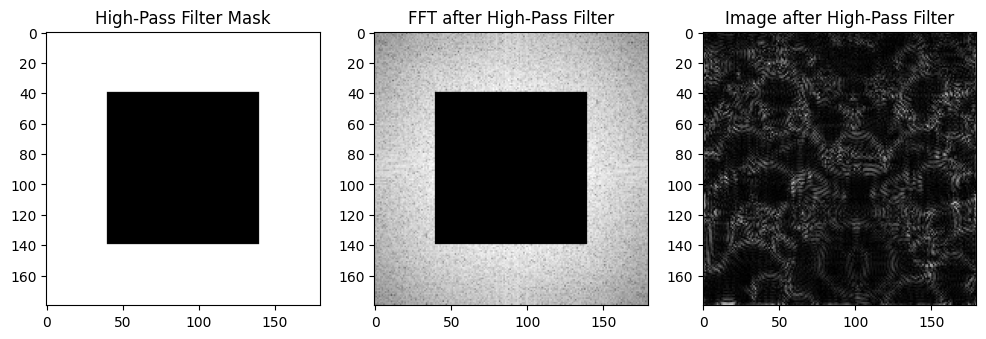

In [12]:
n = 100

high_pass_filter = np.ones(F2.shape)
high_pass_filter[
    (F2.shape[0] // 2 - n // 2) : (F2.shape[0] // 2 + n // 2),
    (F2.shape[1] // 2 - n // 2) : (F2.shape[1] // 2 + n // 2)
] = 0

F2_high_passed = F2 * high_pass_filter

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow((20 * np.log10(0.1 + np.abs(high_pass_filter))).astype(int), cmap="gray")
axes[0].set_title("High-Pass Filter Mask")

axes[1].imshow((20 * np.log10(0.1 + np.abs(F2_high_passed))).astype(int), cmap="gray")
axes[1].set_title("FFT after High-Pass Filter")

axes[2].imshow(np.abs(fftpack.ifft2(fftpack.ifftshift(F2_high_passed))).astype(int), cmap="gray")
axes[2].set_title("Image after High-Pass Filter")

plt.show()

### **TODO 2.2 :** Implement an ideal low-pass filter with a box size of 100x100 pixels on the given image

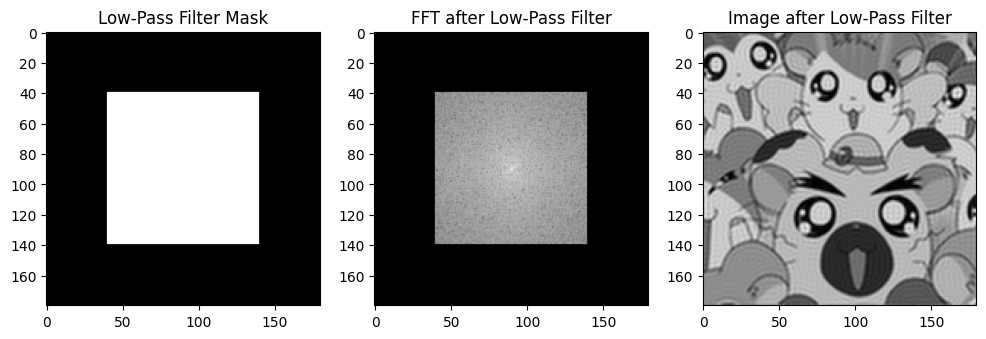

In [13]:
n = 100

low_pass_filter = np.zeros(F2.shape)
low_pass_filter[
    (F2.shape[0] // 2 - n // 2) : (F2.shape[0] // 2 + n // 2),
    (F2.shape[1] // 2 - n // 2) : (F2.shape[1] // 2 + n // 2)
] = 1

F2_low_passed = F2 * low_pass_filter

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow((20 * np.log10(0.1 + np.abs(low_pass_filter))).astype(int), cmap="gray")
axes[0].set_title("Low-Pass Filter Mask")

axes[1].imshow((20 * np.log10(0.1 + np.abs(F2_low_passed))).astype(int), cmap="gray")
axes[1].set_title("FFT after Low-Pass Filter")

axes[2].imshow(np.abs(fftpack.ifft2(fftpack.ifftshift(F2_low_passed))).astype(int), cmap="gray")
axes[2].set_title("Image after Low-Pass Filter")

plt.show()

## Problem 3

A digital signal can be generated from sampling of an analog signal using a periodic impulse-train. Explain how you can reconstruct an analog signal from a digital signal and aliasing problem does not occur when $f_s \leq 2f_{max} $ using frequency analysis.

where $f_s$ is the sampling frequency and $f_{max} $ is the maximum frequency of the analog signal

HINT :  $ \mathscr{F} \left\{ \sum_{n=-\infty}^{\infty} \delta (t-n T_s) \right\} = \sum_{n=-\infty}^{\infty} \delta(\omega - n\omega_s)$ if $\omega_s = \frac{2\pi}{T_s} = 2\pi f_s$


## Problem 4 : Aliasing

### Problem 4.1

The following code generates two sine waves (x01_ts01 and x02_ts01) which are sampled in a range of t = 0,0.05 with sampling rate = 5000 Hz (f_samp_01). Study and write a report to analyze the results.

In [ ]:
t_st = 0
t_end = 0.05
f_01 = 200
f_02 = 2300

f_samp_01 = 5000

ts01 = np.linspace(t_st, t_end , int((t_end-t_st)*f_samp_01), endpoint=False)
x01_ts01 = np.sin(2*np.pi*f_01*ts01)
x02_ts01 = np.sin(2*np.pi*f_02*ts01)

plt.figure(figsize=(20, 5))
plt.plot(ts01, x01_ts01, "go-", ts01, x02_ts01, "r.-")
plt.show()

The sampling rate is reduced to 2500 Hz (f_samp_02). Study and write a report to compare the results.



In [ ]:
f_samp_02 = 2500
ts02 = np.linspace(t_st, t_end , int((t_end-t_st)*f_samp_02), endpoint=False)
x01_ts02 = np.sin(2*np.pi*f_01*ts02)
x02_ts02 = np.sin(2*np.pi*f_02*ts02)

plt.figure(figsize=(20, 5))
plt.plot(ts02, x01_ts02, "go-", ts02, x02_ts02, "r.-")
plt.show()

Ans.

### Problem 4.2
The following code generate audio signals at different frequencies. Play the sound and write a report the analyse the results.

In [ ]:
t_st = 0
t_end = 5
f_01 = 50
f_02 = 22050 - f_01
f_03 = 22050 + f_01
f_samp_02 = 22050

ts02 = np.linspace(t_st, t_end , int((t_end-t_st)*f_samp_02), endpoint=False)

# CREATE SIGNAL WITH DIFFERENT FREQ
x01_ts02 = np.sin(2*np.pi*f_01*ts02)
x02_ts02 = np.sin(2*np.pi*f_02*ts02)
x03_ts02 = np.sin(2*np.pi*f_03*ts02)

In [ ]:
x02_ts02

In [ ]:
ipd.Audio(x01_ts02, rate=f_samp_02)

In [ ]:
ipd.Audio(x02_ts02, rate=f_samp_02)

In [ ]:
ipd.Audio(x03_ts02, rate=f_samp_02)



<a href="https://imgflip.com/i/4djx2z"><img src="https://i.imgflip.com/4djx2z.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator">from Imgflip Meme Generator</a></div>

###  TODO : write report
Ans:

### Problem 4.3
### why many of audio file use sampling rate 44.1 kHz


Ans:

### Problem 5
Download the 3 audio files and analyze all 3 signals with preliminary analysis.
(HINT : Use a log scale for both frequency and magnitude.)"

1. bass-guitar-single-note --> mixkit-bass-guitar-single-note-2331.wav

explain pattern of signal

In [ ]:
!wget https://raw.githubusercontent.com/Pataweepr/ComEngMath2_2023_resource/master/mixkit-adult-sneeze-2212.wav
!wget https://raw.githubusercontent.com/Pataweepr/ComEngMath2_2023_resource/master/mixkit-child-deep-breath-2237.wav
!wget https://raw.githubusercontent.com/Pataweepr/ComEngMath2_2023_resource/master/mixkit-bass-guitar-single-note-2331.wav

---